# Modelo Final

In [57]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import numpy as np

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error


## Leitura do csv

Comecei carregando a planilha anonimizada do desafio analitico e criando uma copia para trabalhar. Assim, qualquer ajuste feito daqui em diante fica separado do original.


In [58]:
caminho_arquivo = Path("../data/dados_anonimizados_2026.xlsx")

if caminho_arquivo.exists():
    df_original = pd.read_excel(caminho_arquivo)

else:
    print("Arquivo não encontrado")
    
df = df_original.copy()


## Data mensal

Como os dados vem separados em ano e mes, criei uma coluna de data com o primeiro dia de cada mes. Isso deixa mais facil ordenar o historico e montar os graficos depois.


In [59]:
df["data"] = (
pd
.to_datetime(
    df["ano"].astype(str) + "-" +
    df["mes"].astype(str) + "-01"
)
)

df.head()


,ano,mes,cidade_agrupada,class_segmentos,abertura_empresas,data
0,2018,1,PORTO ALEGRE,Fisioterapia,1,2018-01-01
1,2018,1,grande_sp,Turismo,11,2018-01-01
2,2018,1,PORTO ALEGRE,Intermediação,4,2018-01-01
3,2018,1,CURITIBA,Eventos,5,2018-01-01
4,2018,1,grande_sp,Fisioterapia,6,2018-01-01


## Base do modelo

Agrupei os dados por mes, cidade agrupada e segmento. Esse nivel faz sentido porque a projecao precisa respeitar diferencas entre regioes e tipos de negocio, e nao apenas o total geral.


In [60]:
base_modelo = (
df
.groupby(
["ano", "mes", "data", "class_segmentos", "cidade_agrupada"], as_index = False)
["abertura_empresas"]
.sum()
.sort_values(["cidade_agrupada", "class_segmentos", "data"])
)


## Passagem do tempo

A variavel `t` marca quantos meses se passaram desde o comeco da base. Ela e uma forma simples de mostrar para o modelo que existe uma sequencia temporal nos dados.


In [61]:
data_minima = base_modelo["data"].min()

base_modelo["t"] = (
(base_modelo["data"].dt.year - data_minima.year) * 12 +
(base_modelo["data"].dt.month - data_minima.month) 
)


## Historico recente

Aqui entram informacoes do passado de cada cidade e segmento: mes anterior, mesmo mes do ano anterior e medias moveis. acabaram gerando um underfit nos testes


In [62]:
base_modelo["aberturas_mes_anterior"] = (
base_modelo
.groupby(["cidade_agrupada", "class_segmentos"])["abertura_empresas"]
.shift(1)
)

base_modelo["aberturas_mesmo_mes_ano_anterior"] = (
base_modelo
.groupby(["cidade_agrupada", "class_segmentos"])["abertura_empresas"]
.shift(12)
)

base_modelo["media_ultimos_3_meses"] = (
base_modelo
.groupby(["cidade_agrupada", "class_segmentos"])["abertura_empresas"]
.transform(lambda x: x.shift(1).rolling(3).mean())
)

base_modelo["media_ultimos_6_meses"] = (
base_modelo
.groupby(["cidade_agrupada", "class_segmentos"])["abertura_empresas"]
.transform(lambda x: x.shift(1).rolling(6).mean())
)

base_modelo = base_modelo.dropna().copy()


## Variaveis usadas

Separei as colunas que entram no modelo. As numericas trazem tempo e historico; as categoricas identificam cidade e segmento.


In [63]:
features_numericas = [
    "ano", "mes", "t", "aberturas_mes_anterior", "aberturas_mesmo_mes_ano_anterior",
    "media_ultimos_3_meses", "media_ultimos_6_meses"
]

features_categoricas = [
    "class_segmentos", "cidade_agrupada"
]
target = "abertura_empresas"


In [64]:
x_final = base_modelo[features_numericas + features_categoricas]

y_final = base_modelo[target]


## Categorias no pipeline

Cidade e segmento sao textos, entao precisam ser convertidos antes do treino. Usei `OneHotEncoder` dentro do pipeline para fazer essa etapa junto com o modelo.


In [65]:
pre_processamento =(
ColumnTransformer(
    transformers = [
        ("categoricas", OneHotEncoder(handle_unknown = "ignore"), features_categoricas),
        ("numericas", "passthrough", features_numericas)
    ]
)
)


## Modelo final

Usei Random Forest com variaveis historicas porque essa versao foi melhor nos testes de validacao.

In [66]:
modelo_final_rf = (
Pipeline(
steps = [
    ("preprocessamneto", pre_processamento),
    ("modelo", RandomForestRegressor(
        n_estimators = 300,
        random_state = 1411,
        min_samples_leaf = 3,
        n_jobs=-1
    )) 
    ])
)


## Validacao do modelo final

Antes de treinar o modelo com toda a base, usei 2025 como teste para ter uma nocao do erro mensal. Esse erro sera usado depois como uma margem simples para a faixa de incerteza da projecao.


In [82]:
def wmape(y_true, y_pred):
    return np.sum(np.abs(y_true - y_pred)) / np.sum(np.abs(y_true))


treino_validacao = base_modelo["ano"] <= 2024
teste_validacao = base_modelo["ano"] == 2025

x_train_validacao = base_modelo.loc[
    treino_validacao,
    features_numericas + features_categoricas
]
y_train_validacao = base_modelo.loc[treino_validacao, target]

x_test_validacao = base_modelo.loc[
    teste_validacao,
    features_numericas + features_categoricas
]
y_test_validacao = base_modelo.loc[teste_validacao, target]

pre_processamento_validacao = ColumnTransformer(
    transformers=[
        ("categoricas", OneHotEncoder(handle_unknown="ignore"), features_categoricas),
        ("numericas", "passthrough", features_numericas)
    ]
)

modelo_validacao_rf = Pipeline(
    steps=[
        ("preprocessamento", pre_processamento_validacao),
        ("modelo", RandomForestRegressor(
            n_estimators=300,
            random_state=1411,
            min_samples_leaf=3,
            n_jobs=-1
        ))
    ]
)

modelo_validacao_rf.fit(x_train_validacao, y_train_validacao)
pred_validacao = modelo_validacao_rf.predict(x_test_validacao)

resultado_validacao = base_modelo.loc[
    teste_validacao,
    ["data", "ano", "mes", "cidade_agrupada", "class_segmentos", "abertura_empresas"]
].copy()

resultado_validacao["previsao_rf_historico"] = pred_validacao

resultado_validacao_mensal = (
    resultado_validacao
    .groupby("data", as_index=False)[["abertura_empresas", "previsao_rf_historico"]]
    .sum()
    .sort_values("data")
)

wmape_rf_historico_mensal = wmape(
    resultado_validacao_mensal["abertura_empresas"],
    resultado_validacao_mensal["previsao_rf_historico"]
)

print(f"O modelo teve uma taxa de erro mensal de: {wmape_rf_historico_mensal:.2%} no teste de 2025")


O modelo teve uma taxa de erro mensal de: 8.83% no teste de 2025


In [68]:
modelo_final_rf.fit(x_final, y_final)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessamneto', ...), ('modelo', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('categoricas', ...), ('numericas', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the differ

## Base para projetar 2026

Antes de prever, preparei as combinacoes de cidade e segmento que aparecem no historico. Tambem deixei separado o historico que sera atualizado mes a mes durante a projecao.


In [69]:
historico_para_previsao = base_modelo[
    [
        "data",
        "ano",
        "mes",
        "cidade_agrupada",
        "class_segmentos",
        "abertura_empresas",
        "t"
    ]
].copy()

historico_para_previsao = historico_para_previsao.sort_values(
    ["cidade_agrupada", "class_segmentos", "data"]
)

combinacoes = base_modelo[
    ["cidade_agrupada", "class_segmentos"]
].drop_duplicates()

datas_2026 = pd.date_range(
    start="2026-01-01",
    end="2026-12-01",
    freq="MS"
)

previsoes_2026 = []


In [70]:
def buscar_aberturas_em_data(historico, data_referencia, nome_coluna):
    resultado = historico.loc[
        historico["data"] == data_referencia,
        ["cidade_agrupada", "class_segmentos", "abertura_empresas"]
        ].copy()

    resultado = resultado.rename(
    columns={"abertura_empresas": nome_coluna}
    )

    return resultado


def calcular_media_recente(historico, data_previsao, janela, nome_coluna):
    resultado = (
    historico[historico["data"] < data_previsao]
        .sort_values(["cidade_agrupada", "class_segmentos", "data"])
        .groupby(["cidade_agrupada", "class_segmentos"])
        .tail(janela)
        .groupby(["cidade_agrupada", "class_segmentos"], as_index=False)["abertura_empresas"]
        .mean()
        .rename(columns={"abertura_empresas": nome_coluna})
    )

    return resultado


## Projecao mes a mes

A previsao de 2026 e feita de forma recursiva. Primeiro o modelo preve janeiro, depois esse valor entra no historico e ajuda a calcular as variaveis de fevereiro, e assim por diante.


In [71]:
for data_previsao in datas_2026:
    base_mes = combinacoes.copy()

    base_mes["data"] = data_previsao
    base_mes["ano"] = data_previsao.year
    base_mes["mes"] = data_previsao.month

    base_mes["t"] = (
        (base_mes["data"].dt.year - data_minima.year) * 12 +
        (base_mes["data"].dt.month - data_minima.month)
    )

    dados_mes_anterior = buscar_aberturas_em_data(
        historico_para_previsao,
        data_previsao - pd.DateOffset(months=1),
        "aberturas_mes_anterior"
    )

    dados_mesmo_mes_ano_anterior = buscar_aberturas_em_data(
        historico_para_previsao,
        data_previsao - pd.DateOffset(years=1),
        "aberturas_mesmo_mes_ano_anterior"
    )

    media_3_meses = calcular_media_recente(
        historico_para_previsao,
        data_previsao,
        3,
        "media_ultimos_3_meses"
    )

    media_6_meses = calcular_media_recente(
        historico_para_previsao,
        data_previsao,
        6,
        "media_ultimos_6_meses"
    )

    base_mes = base_mes.merge(
        dados_mes_anterior,
        on=["cidade_agrupada", "class_segmentos"],
        how="left"
    )

    base_mes = base_mes.merge(
        dados_mesmo_mes_ano_anterior,
        on=["cidade_agrupada", "class_segmentos"],
        how="left"
    )

    base_mes = base_mes.merge(
        media_3_meses,
        on=["cidade_agrupada", "class_segmentos"],
        how="left"
    )

    base_mes = base_mes.merge(
        media_6_meses,
        on=["cidade_agrupada", "class_segmentos"],
        how="left"
    )

    colunas_historicas = [
        "aberturas_mes_anterior",
        "aberturas_mesmo_mes_ano_anterior",
        "media_ultimos_3_meses",
        "media_ultimos_6_meses"
    ]

    base_mes[colunas_historicas] = base_mes[colunas_historicas].fillna(0)

    x_mes = base_mes[
        features_numericas + features_categoricas
    ]

    base_mes["previsao_aberturas"] = modelo_final_rf.predict(x_mes)
    base_mes["previsao_aberturas"] = base_mes["previsao_aberturas"].clip(lower=0)

    previsoes_2026.append(base_mes.copy())

    base_mes_historico = base_mes[
        [
            "data",
            "ano",
            "mes",
            "cidade_agrupada",
            "class_segmentos",
            "previsao_aberturas",
            "t"
        ]
    ].copy()

    base_mes_historico = base_mes_historico.rename(
        columns={"previsao_aberturas": "abertura_empresas"}
    )

    historico_para_previsao = pd.concat(
        [historico_para_previsao, base_mes_historico],
        ignore_index=True
    )


In [72]:
previsao_2026_detalhada = pd.concat(
    previsoes_2026,
    ignore_index=True
)

previsao_2026_mensal = (
    previsao_2026_detalhada
    .groupby(["data", "ano", "mes"], as_index=False)["previsao_aberturas"]
    .sum()
    .sort_values("data")
)

previsao_2026_mensal


,data,ano,mes,previsao_aberturas
0,2026-01-01,2026,1,28220.424665
1,2026-02-01,2026,2,30102.757857
2,2026-03-01,2026,3,31423.394767
3,2026-04-01,2026,4,29516.591031
4,2026-05-01,2026,5,29359.576278
5,2026-06-01,2026,6,28957.421654
6,2026-07-01,2026,7,31228.063305
7,2026-08-01,2026,8,30114.423005
8,2026-09-01,2026,9,29668.524367
9,2026-10-01,2026,10,29998.930632


## Meta de market share




In [73]:
meta_market_share = 0.20

previsao_2026_mensal["meta_vendas_20_market_share"]= (
previsao_2026_mensal["previsao_aberturas"] * meta_market_share
)

previsao_2026_mensal["meta_vendas_20_market_share_arredondada"] = (
np.ceil(previsao_2026_mensal["meta_vendas_20_market_share"])
)

previsao_2026_mensal


,data,ano,mes,previsao_aberturas,meta_vendas_20_market_share,meta_vendas_20_market_share_arredondada
0,2026-01-01,2026,1,28220.424665,5644.084933,5645.0
1,2026-02-01,2026,2,30102.757857,6020.551571,6021.0
2,2026-03-01,2026,3,31423.394767,6284.678953,6285.0
3,2026-04-01,2026,4,29516.591031,5903.318206,5904.0
4,2026-05-01,2026,5,29359.576278,5871.915256,5872.0
5,2026-06-01,2026,6,28957.421654,5791.484331,5792.0
6,2026-07-01,2026,7,31228.063305,6245.612661,6246.0
7,2026-08-01,2026,8,30114.423005,6022.884601,6023.0
8,2026-09-01,2026,9,29668.524367,5933.704873,5934.0
9,2026-10-01,2026,10,29998.930632,5999.786126,6000.0


## Faixa de incerteza da projecao

In [74]:
margem_erro = wmape_rf_historico_mensal

previsao_2026_mensal["limite_inferior"] = (
    previsao_2026_mensal["previsao_aberturas"] * (1 - margem_erro)
)

previsao_2026_mensal["limite_superior"] = (
    previsao_2026_mensal["previsao_aberturas"] * (1 + margem_erro)
)

previsao_2026_mensal["limite_inferior"] = (
    previsao_2026_mensal["limite_inferior"]
    .clip(lower=0)
    .round(0)
)

previsao_2026_mensal["limite_superior"] = (
    previsao_2026_mensal["limite_superior"]
    .round(0)
)

previsao_2026_mensal["meta_20_limite_inferior"] = (
    previsao_2026_mensal["limite_inferior"] * meta_market_share
)

previsao_2026_mensal["meta_20_limite_superior"] = (
    previsao_2026_mensal["limite_superior"] * meta_market_share
)

mercado_anual_minimo = previsao_2026_mensal["limite_inferior"].sum()
mercado_anual_central = previsao_2026_mensal["previsao_aberturas"].sum()
mercado_anual_maximo = previsao_2026_mensal["limite_superior"].sum()

meta_anual_minima = previsao_2026_mensal["meta_20_limite_inferior"].sum()
meta_anual_central = previsao_2026_mensal["meta_vendas_20_market_share"].sum()
meta_anual_maxima = previsao_2026_mensal["meta_20_limite_superior"].sum()

resumo_incerteza = pd.DataFrame({
    "indicador": [
        "Mercado anual - limite inferior",
        "Mercado anual - previsao central",
        "Mercado anual - limite superior",
        "Meta 20% - limite inferior",
        "Meta 20% - previsao central",
        "Meta 20% - limite superior"
    ],
    "valor": [
        mercado_anual_minimo,
        mercado_anual_central,
        mercado_anual_maximo,
        meta_anual_minima,
        meta_anual_central,
        meta_anual_maxima
    ]
})

resumo_incerteza["valor"] = resumo_incerteza["valor"].round(0).astype(int)

resumo_incerteza


,indicador,valor
0,Mercado anual - limite inferior,317420
1,Mercado anual - previsao central,348180
2,Mercado anual - limite superior,378938
3,Meta 20% - limite inferior,63484
4,Meta 20% - previsao central,69636
5,Meta 20% - limite superior,75788


In [75]:
mercado_total_2026 = previsao_2026_mensal["previsao_aberturas"].sum()

meta_anual_20_market_share = previsao_2026_mensal["meta_vendas_20_market_share"].sum()

meta_anual_20_market_share_arredondada = np.ceil(meta_anual_20_market_share)

print(f"Mercado projetado para 2026: {mercado_total_2026:,.0f} empresas abertas")
print(f"Meta anual para 20% de market share: {meta_anual_20_market_share_arredondada:,.0f} vendas")


Mercado projetado para 2026: 348,180 empresas abertas
Meta anual para 20% de market share: 69,637 vendas


In [76]:
tabela_market_share = previsao_2026_mensal[
    [
        "data",
        "mes",
        "previsao_aberturas",
        "limite_inferior",
        "limite_superior",
        "meta_vendas_20_market_share_arredondada",
        "meta_20_limite_inferior",
        "meta_20_limite_superior"
    ]
].copy()

tabela_market_share = tabela_market_share.rename(columns={
    "data": "data",
    "mes": "mes",
    "previsao_aberturas": "mercado_projetado",
    "limite_inferior": "mercado_limite_inferior",
    "limite_superior": "mercado_limite_superior",
    "meta_vendas_20_market_share_arredondada": "meta_vendas_20_market_share",
    "meta_20_limite_inferior": "meta_20_limite_inferior",
    "meta_20_limite_superior": "meta_20_limite_superior"
})

tabela_market_share


,data,mes,mercado_projetado,mercado_limite_inferior,mercado_limite_superior,meta_vendas_20_market_share,meta_20_limite_inferior,meta_20_limite_superior
0,2026-01-01,1,28220.424665,25727.0,30713.0,5645.0,5145.4,6142.6
1,2026-02-01,2,30102.757857,27443.0,32762.0,6021.0,5488.6,6552.4
2,2026-03-01,3,31423.394767,28647.0,34199.0,6285.0,5729.4,6839.8
3,2026-04-01,4,29516.591031,26909.0,32124.0,5904.0,5381.8,6424.8
4,2026-05-01,5,29359.576278,26766.0,31953.0,5872.0,5353.2,6390.6
5,2026-06-01,6,28957.421654,26399.0,31516.0,5792.0,5279.8,6303.2
6,2026-07-01,7,31228.063305,28469.0,33987.0,6246.0,5693.8,6797.4
7,2026-08-01,8,30114.423005,27454.0,32775.0,6023.0,5490.8,6555.0
8,2026-09-01,9,29668.524367,27048.0,32289.0,5934.0,5409.6,6457.8
9,2026-10-01,10,29998.930632,27349.0,32649.0,6000.0,5469.8,6529.8


## Historico e projecao

Este grafico coloca o historico mensal e a projecao de 2026 na mesma visao.

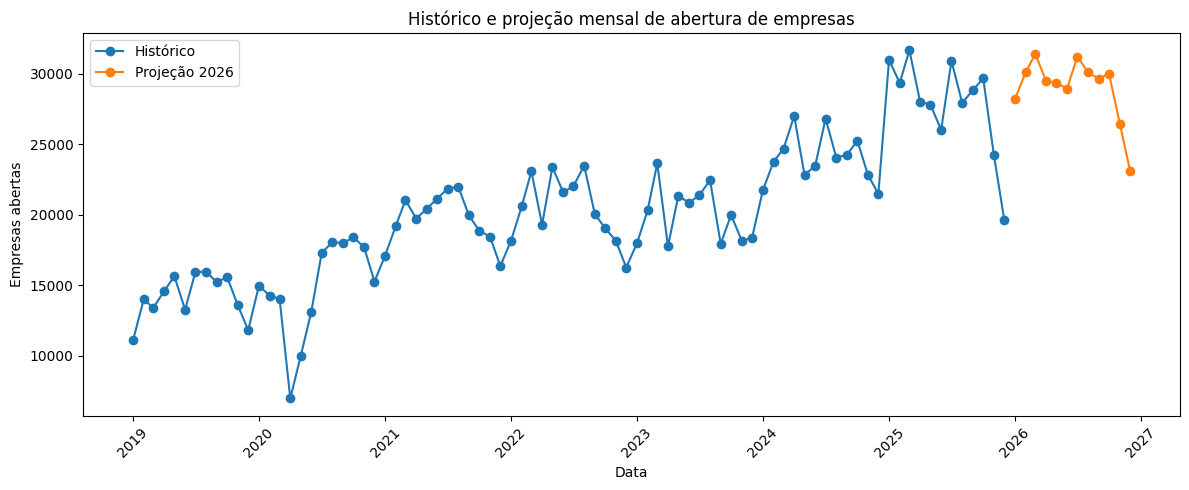

In [77]:
historico_mensal = (
base_modelo
.groupby("data", as_index=False)["abertura_empresas"]
.sum()
.sort_values("data")
)

plt.figure(figsize=(12, 5))

plt.plot(
    historico_mensal["data"],
    historico_mensal["abertura_empresas"],
    marker="o",
    label="Histórico"
)

plt.plot(
    previsao_2026_mensal["data"],
    previsao_2026_mensal["previsao_aberturas"],
    marker="o",
    label="Projeção 2026"
)

plt.title("Histórico e projeção mensal de abertura de empresas")
plt.xlabel("Data")
plt.ylabel("Empresas abertas")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()


## Grafico com faixa de incerteza

Neste grafico, a linha principal continua sendo a previsao central. A area sombreada mostra uma faixa operacional baseada no erro observado na validacao.


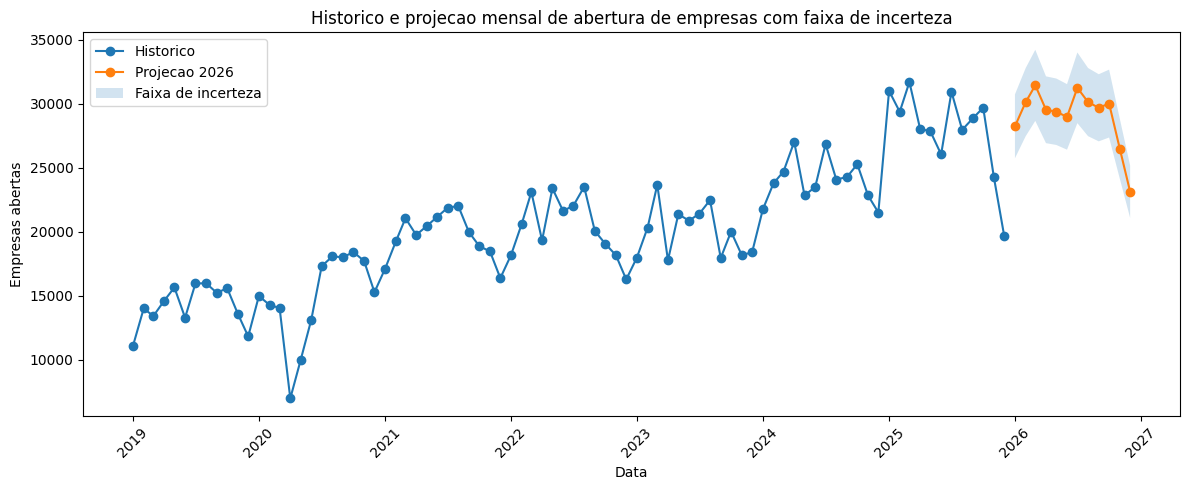

In [78]:
plt.figure(figsize=(12, 5))

plt.plot(
    historico_mensal["data"],
    historico_mensal["abertura_empresas"],
    marker="o",
    label="Historico"
)

plt.plot(
    previsao_2026_mensal["data"],
    previsao_2026_mensal["previsao_aberturas"],
    marker="o",
    label="Projecao 2026"
)

plt.fill_between(
    previsao_2026_mensal["data"],
    previsao_2026_mensal["limite_inferior"],
    previsao_2026_mensal["limite_superior"],
    alpha=0.2,
    label="Faixa de incerteza"
)

plt.title("Historico e projecao mensal de abertura de empresas com faixa de incerteza")
plt.xlabel("Data")
plt.ylabel("Empresas abertas")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()


## Meta mensal

Alem do total do ano, quebrei a meta por mes. Isso ajuda a enxergar quais meses exigiriam mais vendas para manter a ideia de 20% de market share.


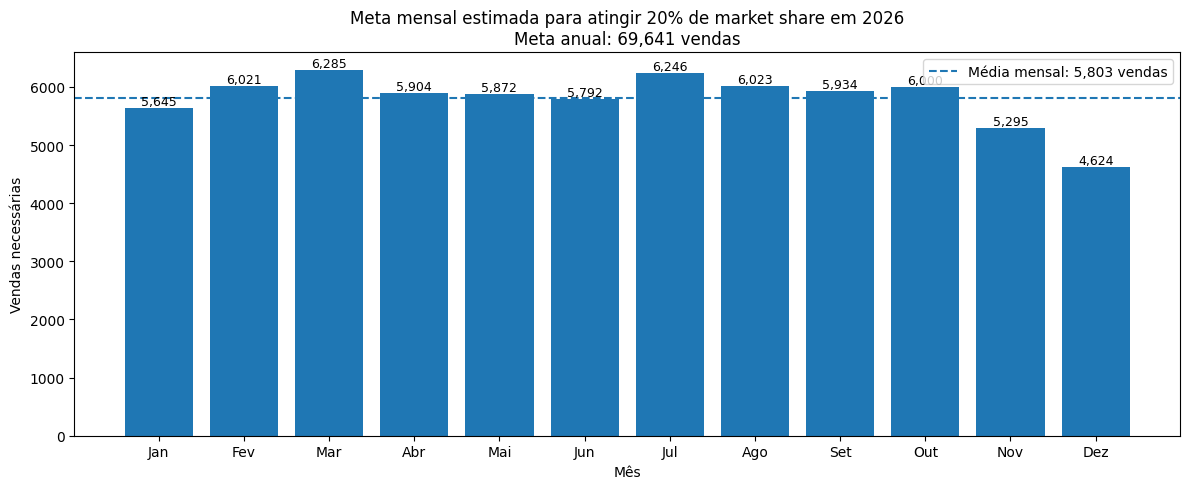

In [79]:
meses_nome = [
    "Jan", "Fev", "Mar", "Abr", "Mai", "Jun",
    "Jul", "Ago", "Set", "Out", "Nov", "Dez"
]

previsao_2026_mensal["mes_nome"] = meses_nome

meta_anual = previsao_2026_mensal["meta_vendas_20_market_share_arredondada"].sum()
media_mensal_meta = previsao_2026_mensal["meta_vendas_20_market_share_arredondada"].mean()

plt.figure(figsize=(12, 5))

plt.bar(
    previsao_2026_mensal["mes_nome"],
    previsao_2026_mensal["meta_vendas_20_market_share_arredondada"]
)

plt.axhline(
    media_mensal_meta,
    linestyle="--",
    label=f"Média mensal: {media_mensal_meta:,.0f} vendas"
)

for i, valor in enumerate(previsao_2026_mensal["meta_vendas_20_market_share_arredondada"]):
    plt.text(
        i,
        valor,
        f"{valor:,.0f}",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.title(f"Meta mensal estimada para atingir 20% de market share em 2026\nMeta anual: {meta_anual:,.0f} vendas")
plt.xlabel("Mês")
plt.ylabel("Vendas necessárias")
plt.legend()
plt.tight_layout()
plt.show()


## Resumo executivo




In [80]:
resumo_market_share = pd.DataFrame({
    "indicador": [
        "Mercado projetado em 2026",
        "Meta anual para 20% de market share",
        "Média mensal de vendas necessárias"
    ],
    "valor": [
        mercado_total_2026,
        meta_anual_20_market_share_arredondada,
        media_mensal_meta
    ]
})

resumo_market_share["valor"] = resumo_market_share["valor"].round(0).astype(int)

resumo_market_share


,indicador,valor
0,Mercado projetado em 2026,348180
1,Meta anual para 20% de market share,69637
2,Média mensal de vendas necessárias,5803


## Arquivos para o streamlit

In [81]:
pasta_outputs = Path("../outputs")
pasta_outputs.mkdir(exist_ok=True)

historico_mensal.to_csv(pasta_outputs / "historico_mensal.csv", index=False)
previsao_2026_mensal.to_csv(pasta_outputs / "previsao_2026_mensal.csv", index=False)
tabela_market_share.to_csv(pasta_outputs / "tabela_market_share.csv", index=False)
resumo_market_share.to_csv(pasta_outputs / "resumo_market_share.csv", index=False)
resumo_incerteza.to_csv(pasta_outputs / "resumo_incerteza.csv", index=False)
